## Importando as bibliotecas

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Bibliotecas Importadas com Sucesso!!")

Bibliotecas Importadas com Sucesso!!


## Leitura e verificação dos Dados

In [2]:
dados = pd.read_csv("../data/dados_housing.csv")
dados.head()

,longitude,latitude,idade_mediana_imoveis,total_comodos,total_quartos,populacao,domicilios,renda_media,valor_media_imovel,proximidade_oceano
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,proximo_baia
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,proximo_baia
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,proximo_baia
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,proximo_baia
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,proximo_baia


In [3]:
print(f"Total Linhas -> {dados.shape[0]}")
print(f"Total Colunas -> {dados.shape[1]}\n")
print(dados.info())

Total Linhas -> 20640
Total Colunas -> 10

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   longitude              20640 non-null  float64
 1   latitude               20640 non-null  float64
 2   idade_mediana_imoveis  20640 non-null  float64
 3   total_comodos          20640 non-null  float64
 4   total_quartos          20433 non-null  float64
 5   populacao              20640 non-null  float64
 6   domicilios             20640 non-null  float64
 7   renda_media            20640 non-null  float64
 8   valor_media_imovel     20640 non-null  float64
 9   proximidade_oceano     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.6 MB
None


In [4]:
print("Verificando Dados Nulos")
print(dados.isna().sum())

Verificando Dados Nulos
longitude                  0
latitude                   0
idade_mediana_imoveis      0
total_comodos              0
total_quartos            207
populacao                  0
domicilios                 0
renda_media                0
valor_media_imovel         0
proximidade_oceano         0
dtype: int64


## Analisando Preço do Imovel

In [5]:
# Pegando os dados estatísticos dos preços
dados['valor_media_imovel'].describe().round(2)

count     20640.00
mean     206855.82
std      115395.62
min       14999.00
25%      119600.00
50%      179700.00
75%      264725.00
max      500001.00
Name: valor_media_imovel, dtype: float64

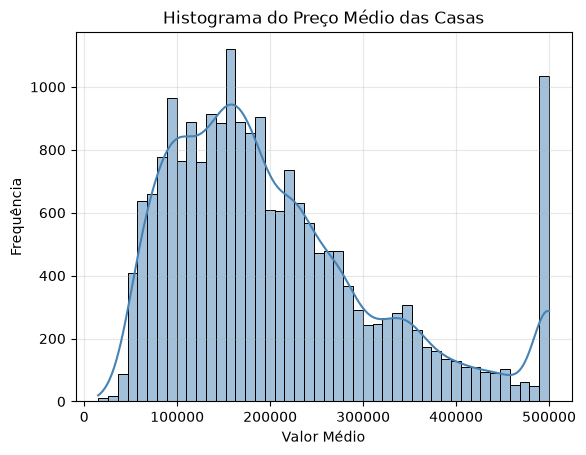

In [6]:
sns.histplot(data=dados, x='valor_media_imovel', kde=True, color='steelblue')
plt.title('Histograma do Preço Médio das Casas')
plt.xlabel('Valor Médio')
plt.ylabel("Frequência")
plt.grid(alpha=0.3)
plt.show()

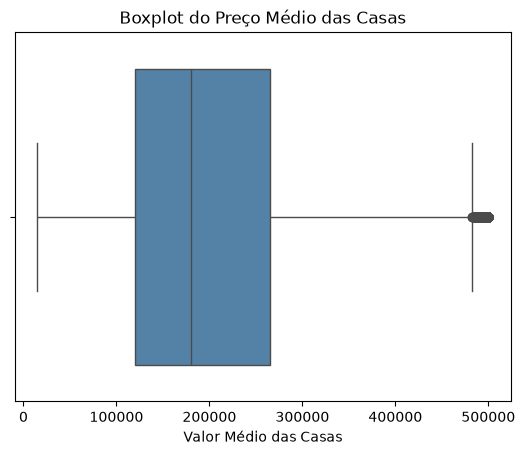

In [7]:
sns.boxplot(data=dados, x='valor_media_imovel', color='steelblue')
plt.title("Boxplot do Preço Médio das Casas")
plt.xlabel("Valor Médio das Casas")
plt.show()

## Valores das casas por Localização

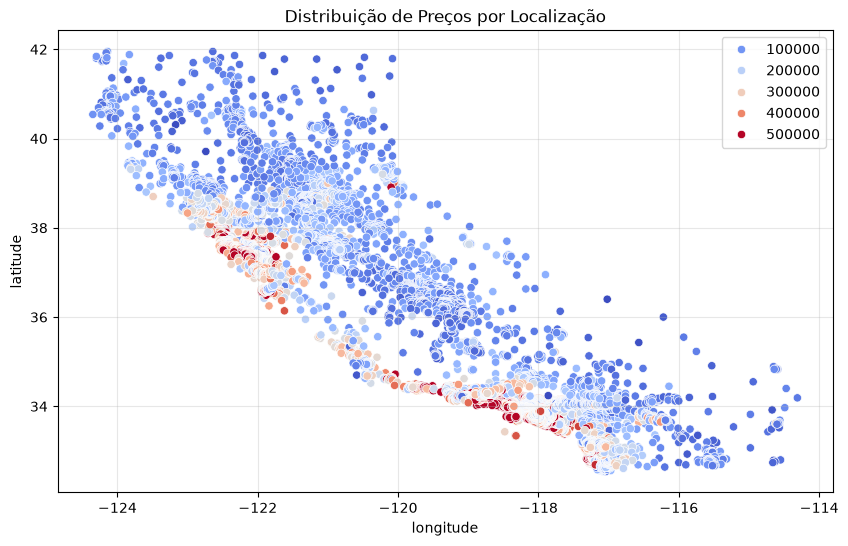

In [8]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=dados, x='longitude', y='latitude', hue='valor_media_imovel', palette='coolwarm')
plt.title('Distribuição de Preços por Localização')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [9]:
preco_oceano = (
    dados.groupby("proximidade_oceano")["valor_media_imovel"]
    .agg(
        quantidade="count",
        media="mean",
        mediana="median",
        desvio_padrao="std",
        minimo="min",
        maximo="max"
    )
    .sort_values("media", ascending=False)
).round(2)

preco_oceano

,quantidade,media,mediana,desvio_padrao,minimo,maximo
proximidade_oceano,,,,,,
ilha,5,380440.00,414700.0,80559.56,287500.0,450000.0
proximo_baia,2290,259212.31,233800.0,122818.54,22500.0,500001.0
proximo_oceano,2658,249433.98,229450.0,122477.15,22500.0,500001.0
menos_1h_oceano,9136,240084.29,214850.0,106124.29,17500.0,500001.0
interior,6551,124805.39,108500.0,70007.91,14999.0,500001.0


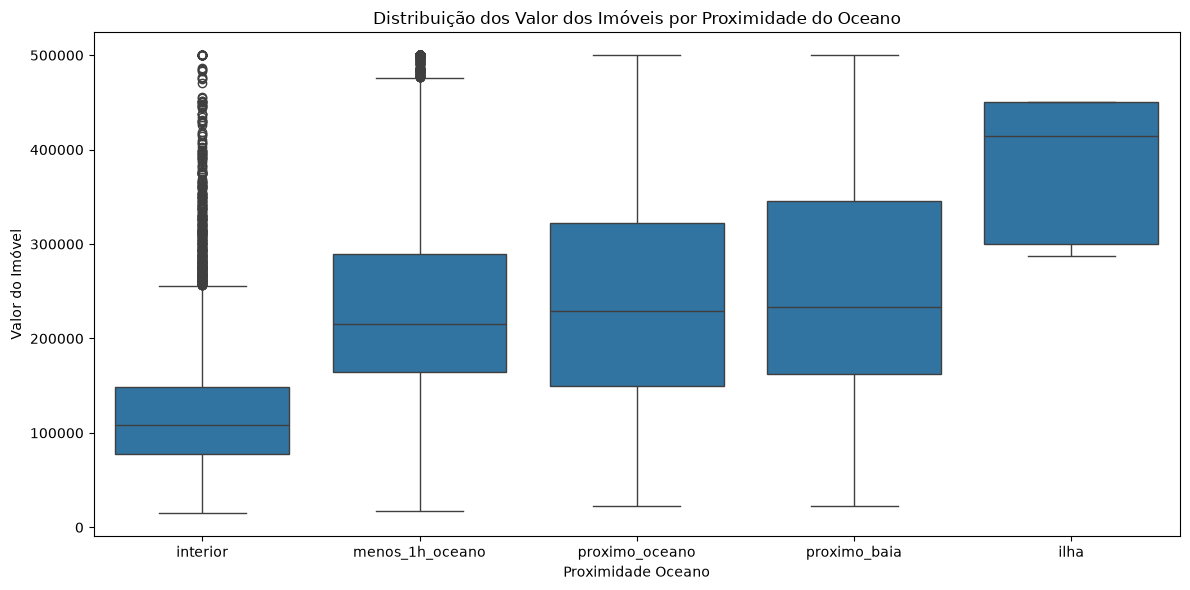

In [11]:
plt.figure(figsize=(12,6))

sns.boxplot(data=dados, x='proximidade_oceano', y='valor_media_imovel',
            order=["interior", "menos_1h_oceano", "proximo_oceano", "proximo_baia", "ilha"])
plt.title("Distribuição dos Valor dos Imóveis por Proximidade do Oceano")
plt.xlabel("Proximidade Oceano")
plt.ylabel("Valor do Imóvel")
plt.tight_layout()
plt.show()

## Classificando preços dos Imóveis

In [12]:
dados['classe'] = pd.cut(dados['valor_media_imovel'],
                         bins=[0., 120000., 250000., 400000., np.inf],
                         labels=["Baixo", "Médio", "Alto", "Luxo"])
dados.head()

,longitude,latitude,idade_mediana_imoveis,total_comodos,total_quartos,populacao,domicilios,renda_media,valor_media_imovel,proximidade_oceano,classe
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,proximo_baia,Luxo
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,proximo_baia,Alto
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,proximo_baia,Alto
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,proximo_baia,Alto
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,proximo_baia,Alto


In [13]:
# Verificando a sua distribuição das classes
dados['classe'].value_counts().sort_values(ascending=False)

classe
Médio    9668
Baixo    5190
Alto     4038
Luxo     1744
Name: count, dtype: int64

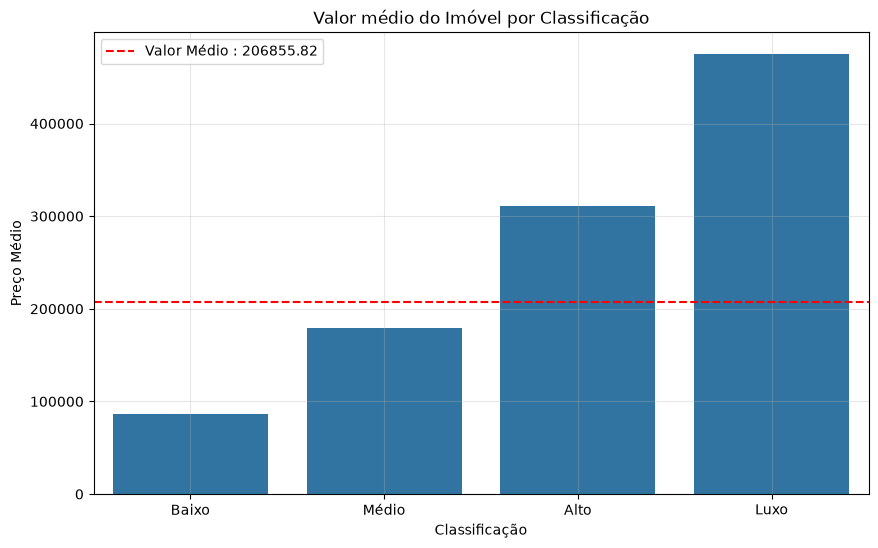

In [14]:
valor_medio = dados.groupby('classe')['valor_media_imovel'].mean()
valor_medio_dados = dados['valor_media_imovel'].mean().round(2)

plt.figure(figsize=(10, 6))
sns.barplot(x=valor_medio.index, y=valor_medio.values)
plt.axhline(valor_medio_dados, color="red", linestyle="--", label=f"Valor Médio : {valor_medio_dados}")
plt.title("Valor médio do Imóvel por Classificação")
plt.xlabel("Classificação")
plt.ylabel("Preço Médio")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## Verificando os dados numéricos em relação ao Preço do Imóvel

In [17]:
var_numericas = ['longitude','latitude','idade_mediana_imoveis','total_comodos','total_quartos','populacao','domicilios','renda_media']

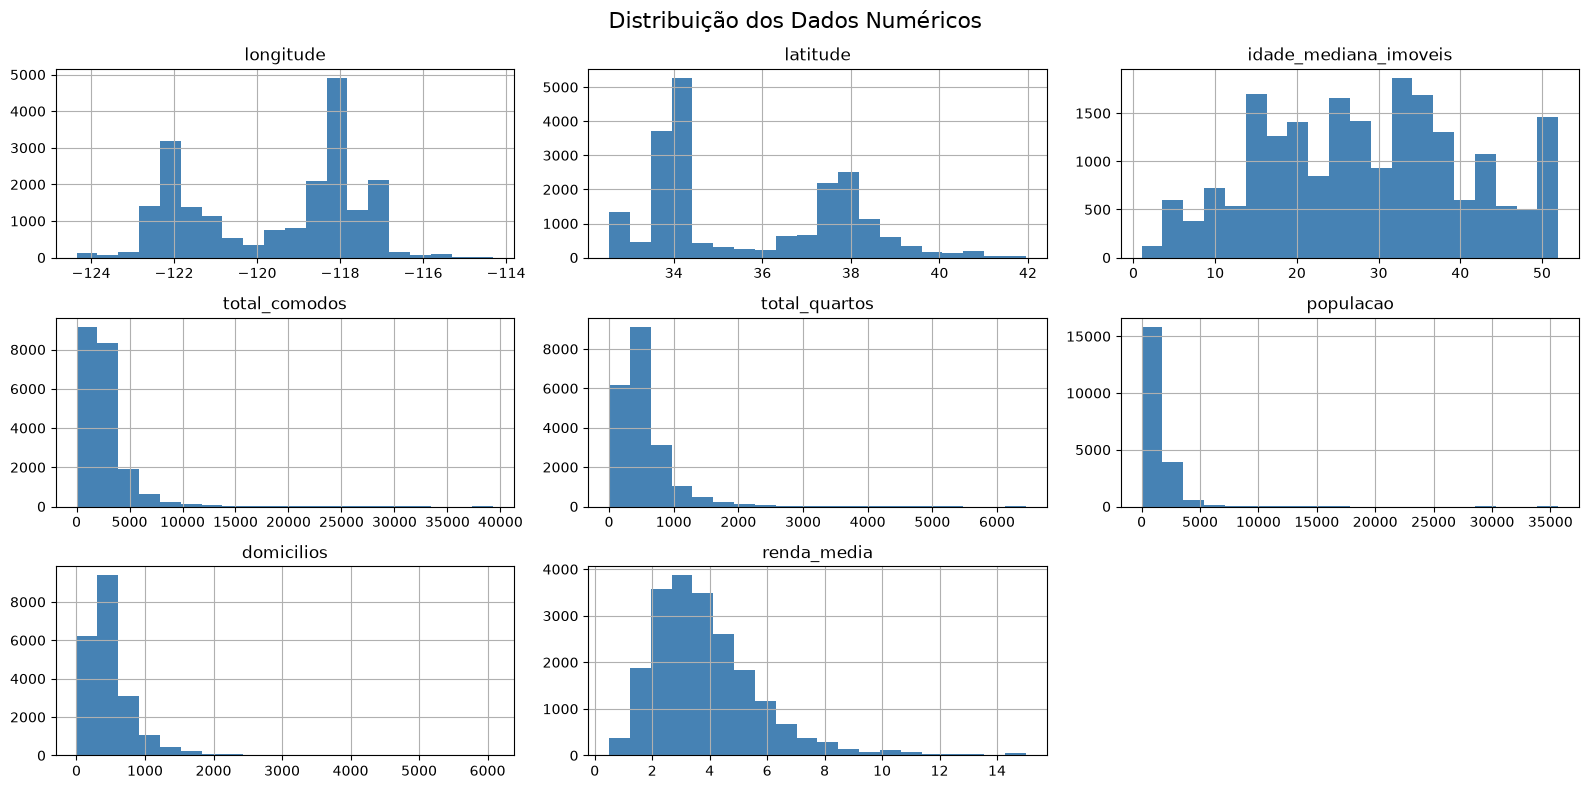

In [23]:
dados[var_numericas].hist(figsize=(16, 8), bins=20, color="steelblue")
plt.suptitle("Distribuição dos Dados Numéricos", fontsize=16)
plt.tight_layout()
plt.show()

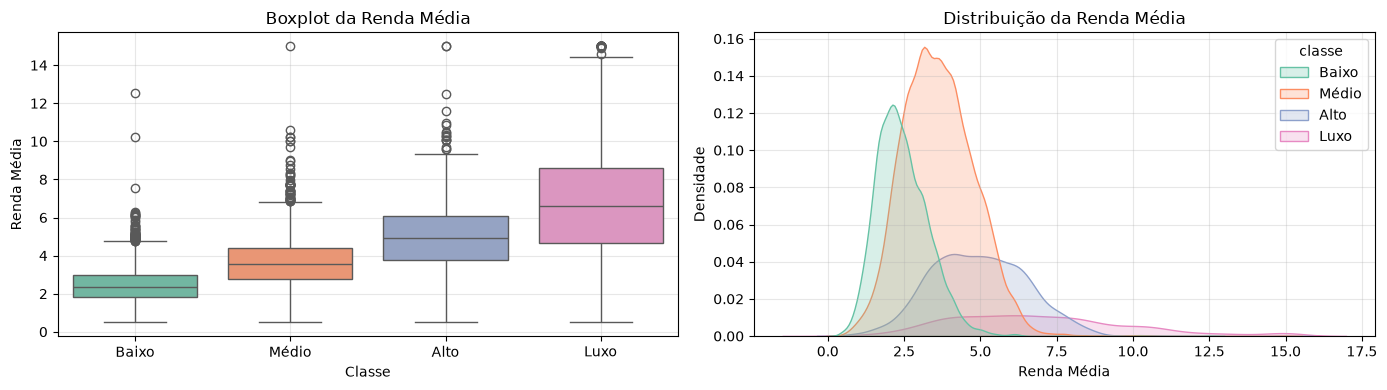

In [28]:
fig, ax = plt.subplots(1, 2, figsize=(14, 4))
palette = "Set2"

# Boxplot
sns.boxplot(data=dados, x='classe', y='renda_media', ax=ax[0], palette=palette, hue='classe', legend=False, dodge=False)
ax[0].set_title("Boxplot da Renda Média")
ax[0].set_xlabel("Classe")
ax[0].set_ylabel("Renda Média")
ax[0].grid(alpha=0.3)

# Kdeplot
sns.kdeplot(data=dados, x='renda_media', hue='classe', fill=True, ax=ax[1], palette=palette)
ax[1].set_title("Distribuição da Renda Média")
ax[1].set_xlabel("Renda Média")
ax[1].set_ylabel("Densidade")
ax[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [30]:
var_correlacao = ['longitude','latitude','idade_mediana_imoveis','total_comodos','total_quartos','populacao','domicilios',
                  'renda_media','valor_media_imovel']

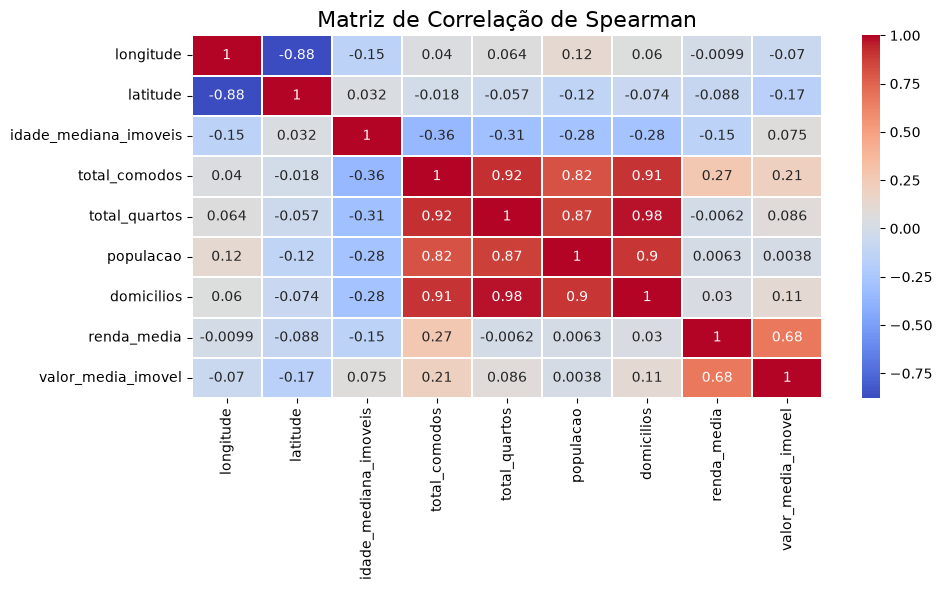

In [32]:
matriz_corr = (dados[var_correlacao].corr(method="spearman"))

plt.figure(figsize=(10,6))

sns.heatmap(matriz_corr, annot=True, cmap='coolwarm', linewidths=0.3)
plt.title("Matriz de Correlação de Spearman", fontsize=16)
plt.tight_layout()
plt.show()

In [33]:
corr_target = (matriz_corr["valor_media_imovel"].drop("valor_media_imovel").sort_values(key=abs, ascending=False))
corr_target

renda_media              0.676778
total_comodos            0.205952
latitude                -0.165739
domicilios               0.112737
total_quartos            0.086259
idade_mediana_imoveis    0.074855
longitude               -0.069667
populacao                0.003839
Name: valor_media_imovel, dtype: float64

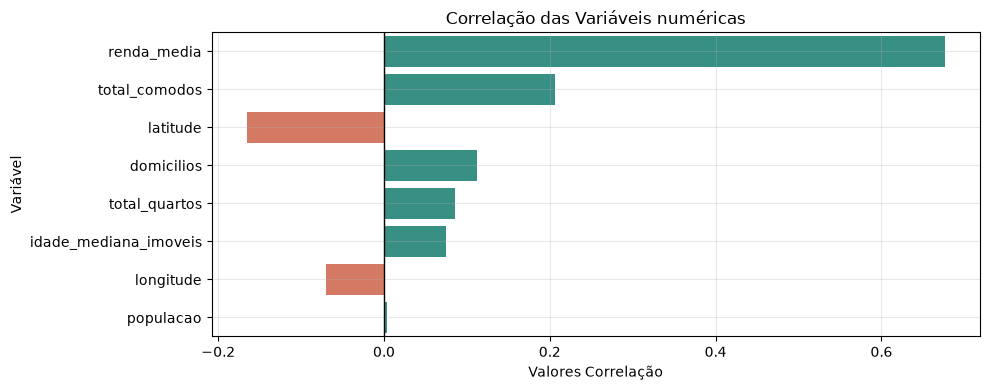

In [37]:
plt.figure(figsize=(10,4))

cores = ["#2a9d8f" if valor >= 0 else "#e76f51"
         for valor in corr_target.values]

sns.barplot(x=corr_target.values, y=corr_target.index, hue=corr_target.index, palette=cores, legend=False)
plt.axvline(0, color='black', linewidth=1)
plt.title("Correlação das Variáveis numéricas")
plt.xlabel("Valores Correlação")
plt.ylabel("Variável")
plt.tight_layout()
plt.grid(alpha=0.3)
plt.show()

## Analisando variável categórica

In [38]:
frequencia = (dados["proximidade_oceano"].value_counts().to_frame("quantidade"))

frequencia["percentual"] = (frequencia["quantidade"] / len(dados) *100).round(2)

print(frequencia)

                    quantidade  percentual
proximidade_oceano                        
menos_1h_oceano           9136       44.26
interior                  6551       31.74
proximo_oceano            2658       12.88
proximo_baia              2290       11.09
ilha                         5        0.02


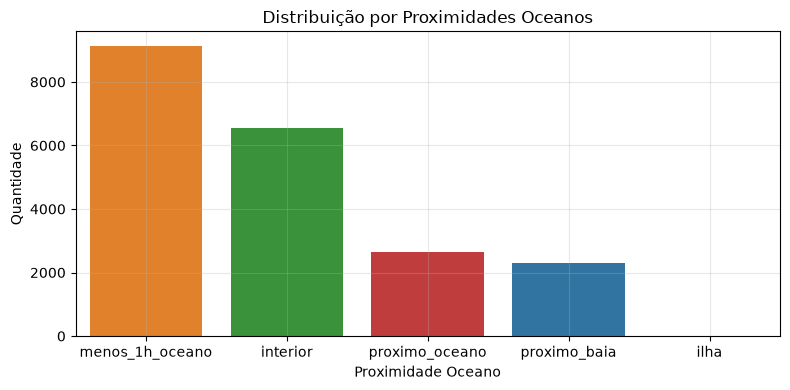

In [44]:
plt.figure(figsize=(8,4))

sns.countplot(data=dados, x="proximidade_oceano",order=dados["proximidade_oceano"].value_counts().index, hue="proximidade_oceano", legend=False)
plt.title("Distribuição por Proximidades Oceanos")
plt.xlabel("Proximidade Oceano")
plt.ylabel("Quantidade")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [46]:
analise_categoria = (
    dados.groupby("proximidade_oceano")["valor_media_imovel"]
    .agg(
        quantidade="count",
        media="mean",
        mediana="median",
        desvio_padrao="std",
        minimo="min",
        maximo="max"
    )
    .sort_values(by="media", ascending=False).round(2)
)
analise_categoria

,quantidade,media,mediana,desvio_padrao,minimo,maximo
proximidade_oceano,,,,,,
ilha,5,380440.00,414700.0,80559.56,287500.0,450000.0
proximo_baia,2290,259212.31,233800.0,122818.54,22500.0,500001.0
proximo_oceano,2658,249433.98,229450.0,122477.15,22500.0,500001.0
menos_1h_oceano,9136,240084.29,214850.0,106124.29,17500.0,500001.0
interior,6551,124805.39,108500.0,70007.91,14999.0,500001.0


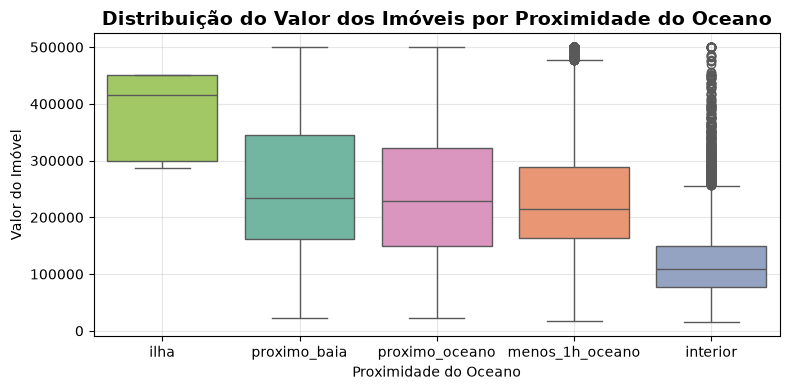

In [ ]:
plt.figure(figsize=(8, 4))

sns.boxplot(data=dados, x="proximidade_oceano", y="valor_media_imovel", hue="proximidade_oceano", order=["ilha", "proximo_baia", "proximo_oceano", "menos_1h_oceano", "interior"], palette="Set2", legend=False)

plt.title("Distribuição do Valor dos Imóveis por Proximidade do Oceano", fontsize=14, fontweight="bold")

plt.xlabel("Proximidade do Oceano")
plt.ylabel("Valor do Imóvel")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Relação entre Renda e Preço

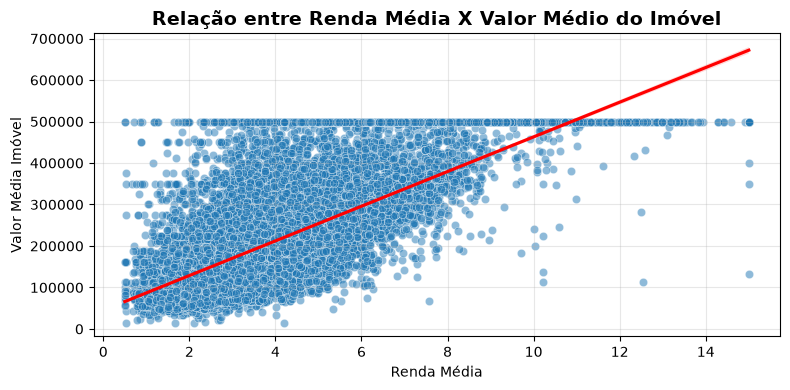

In [51]:
plt.figure(figsize=(8, 4))

sns.scatterplot(data=dados, x="renda_media", y="valor_media_imovel", alpha=0.5)
sns.regplot(data=dados, x="renda_media", y="valor_media_imovel", scatter=False, color="red")

plt.title("Relação entre Renda Média X Valor Médio do Imóvel", fontsize=14, fontweight="bold")
plt.xlabel("Renda Média")
plt.ylabel("Valor Média Imóvel")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()